## 0. Setup

In [1]:
import os, re, time, json, random, platform, math, warnings
from collections import Counter
from functools import lru_cache
import numpy as np, pandas as pd, psutil
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")

# ---------- EDIT THESE ----------
MEMBER   = "Samruddhi"     # used in export file names
SEED     = 42
N_TRAIN  = 200_000         # stratified subsample of the 560k train set; None = use everything (slower)
VAL_FRAC = 0.10
MIN_FREQ, MAX_VOCAB = 3, 50_000
MAX_LEN_CAP = 256


MIN_FREQ, MAX_VOCAB = 2, 30_000
MAX_LEN_CAP = 200



# --------------------------------

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def hardware_string():
    cpu = platform.processor() or platform.machine()
    try:
        for l in open("/proc/cpuinfo"):
            if "model name" in l: cpu = l.split(":")[1].strip(); break
    except Exception: pass
    s = f"CPU: {cpu} ({psutil.cpu_count(logical=True)} threads, {psutil.virtual_memory().total/1e9:.1f} GB RAM)"
    if torch.cuda.is_available():
        p = torch.cuda.get_device_properties(0)
        s += f" | GPU: {torch.cuda.get_device_name(0)} ({p.total_memory/1e9:.1f} GB)"
    return s
HW = hardware_string(); print(HW, "| training device:", DEVICE)

CPU: Intel64 Family 6 Model 154 Stepping 3, GenuineIntel (20 threads, 16.8 GB RAM) | GPU: NVIDIA GeForce RTX 3060 Laptop GPU (6.4 GB) | training device: cuda


## 1. Getting the dataset

In [2]:
from datasets import load_dataset
ds = load_dataset("fancyzhx/yelp_polarity")
train_full = ds["train"].to_pandas()[["text","label"]]
test_df    = ds["test"].to_pandas()[["text","label"]]
print(train_full.shape, test_df.shape)

(560000, 2) (38000, 2)


## 2.1 Data preprocessing
### 1. Length distribution, class distribution, balance

0    0.5
1    0.5
Name: class share, dtype: float64
count    560000.0
mean        133.0
std         122.6
min           1.0
50%          97.0
75%         174.0
90%         282.0
95%         372.0
99%         608.0
max        1052.0
Name: n_words, dtype: float64


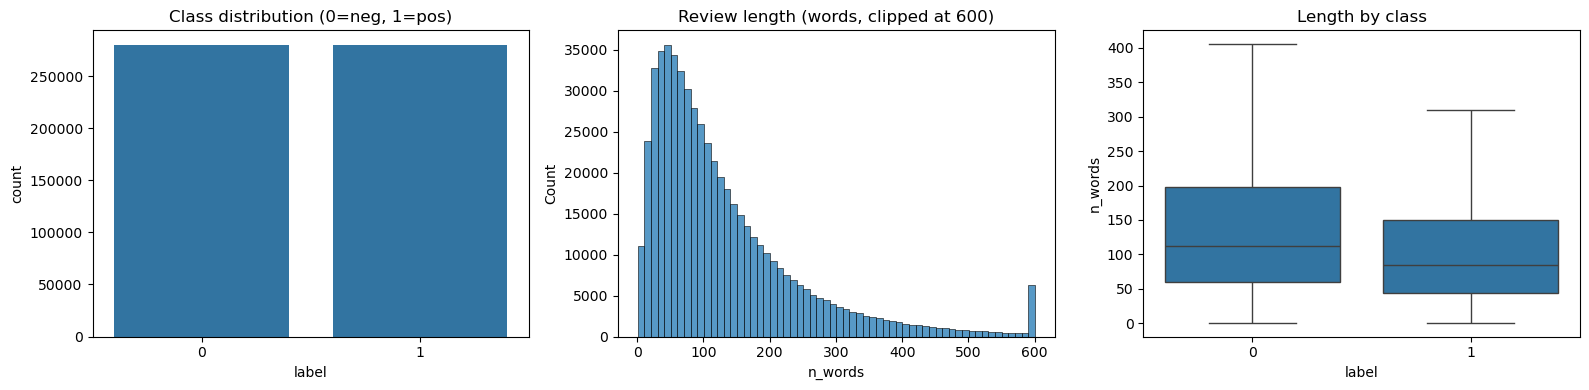

In [3]:
train_full["n_words"] = train_full.text.str.split().str.len()
print(train_full.label.value_counts(normalize=True).rename("class share"))
print(train_full.n_words.describe(percentiles=[.5,.75,.9,.95,.99]).round(1))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(x="label", data=train_full, ax=ax[0]); ax[0].set_title("Class distribution (0=neg, 1=pos)")
sns.histplot(train_full.n_words.clip(upper=600), bins=60, ax=ax[1]); ax[1].set_title("Review length (words, clipped at 600)")
sns.boxplot(x="label", y="n_words", data=train_full.assign(n_words=train_full.n_words.clip(upper=600)), ax=ax[2], showfliers=False)
ax[2].set_title("Length by class"); plt.tight_layout(); plt.show()

### 2. Missing values / malformed entries

In [4]:
def audit(df, name):
    print(f"[{name}] nulls: {df.isna().sum().to_dict()} | empty/whitespace: {(df.text.str.strip()=='').sum()} "
          f"| exact duplicate texts: {df.text.duplicated().sum()} | bad labels: {(~df.label.isin([0,1])).sum()}")
audit(train_full, "train"); audit(test_df, "test")

def clean_frame(df):
    df = df.dropna(subset=["text","label"]).copy()
    df = df[df.text.str.strip() != ""]
    return df.drop_duplicates(subset="text").reset_index(drop=True)
train_full = clean_frame(train_full.drop(columns="n_words")); 
# NOTE: do not drop test rows (keeps test order identical across teammates). Just verify it is clean:
assert test_df.text.notna().all() and (test_df.text.str.strip()!="").all()

# stratified subsample, then train/val split (test set is only used once, at the end)
if N_TRAIN: train_full = train_full.groupby("label", group_keys=False).apply(lambda g: g.sample(N_TRAIN//2, random_state=SEED))
train_full = train_full.sample(frac=1, random_state=SEED).reset_index(drop=True)
n_val = int(len(train_full)*VAL_FRAC)
val_df, train_df = train_full.iloc[:n_val].reset_index(drop=True), train_full.iloc[n_val:].reset_index(drop=True)
print(len(train_df), len(val_df), len(test_df))

[train] nulls: {'text': 0, 'label': 0, 'n_words': 0} | empty/whitespace: 0 | exact duplicate texts: 0 | bad labels: 0
[test] nulls: {'text': 0, 'label': 0} | empty/whitespace: 0 | exact duplicate texts: 0 | bad labels: 0
504000 56000 38000


### 3. Text preprocessing
- Lowercase → expand contractions → strip punctuation/special characters → stopword removal → lemmatisation.
- NLTK's stopword list contains negations (`not`, `no`, `nor`, `don`, `didn`…) and intensifiers/contrast words (`but`, `very`, `too`). Removing them flips or erases sentiment ("not good" → "good"), so they are kept. Contractions are expanded first (`didn't` → `did not`) so the negation survives punctuation stripping

In [5]:
import nltk
for p in ["stopwords","wordnet","omw-1.4"]: nltk.download(p, quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

KEEP = {"no","nor","not","never","but","very","too","against","only","few","more","most","than","off","down"}
STOP = set(stopwords.words("english")) - KEEP
_lem = WordNetLemmatizer()
@lru_cache(maxsize=None)
def lemma(w): return _lem.lemmatize(w)

def clean(t):
    t = t.lower().replace("\\n", " ")
    t = re.sub(r"won't", "will not", t); t = re.sub(r"can't|cannot", "can not", t)
    t = re.sub(r"n't\b", " not", t)
    t = re.sub(r"[^a-z0-9\s]", " ", t)          # punctuation + special characters
    return re.sub(r"\s+", " ", t).strip()

def tokenize(t):                                   # 4. tokenisation (whitespace after cleaning) + stopwords + lemma
    return [lemma(w) for w in clean(t).split() if w not in STOP]

print("RAW  :", train_df.text[0][:300]); print("TOKEN:", tokenize(train_df.text[0])[:40])

RAW  : I love Venice, so after staying at the Palms, Hardrock and the Wynn I decided it was time to stay in Italian luxury. I picked New Years Eve to do this......so I'll admit, my review may be a bit off for normal stays.\nThe boy and I arrived at 10am, jumped in a cab, and pulled up to the splendor that 
TOKEN: ['love', 'venice', 'staying', 'palm', 'hardrock', 'wynn', 'decided', 'time', 'stay', 'italian', 'luxury', 'picked', 'new', 'year', 'eve', 'admit', 'review', 'may', 'bit', 'off', 'normal', 'stay', 'boy', 'arrived', '10am', 'jumped', 'cab', 'pulled', 'splendor', 'venetian', 'got', 'enormous', 'line', 'check', 'concierge', 'came', 'u', 'escorted', 'u', 'second']


In [6]:
t0 = time.time()
for d in (train_df, val_df, test_df): d["tokens"] = d.text.map(tokenize)
print(f"tokenised in {time.time()-t0:.0f}s")
tok_len = train_df.tokens.str.len()
print("tokens/review:", tok_len.describe(percentiles=[.5,.9,.95,.99]).round(1).to_dict())

tokenised in 117s
tokens/review: {'count': 504000.0, 'mean': 72.7, 'std': 66.0, 'min': 0.0, '50%': 53.0, '90%': 153.0, '95%': 201.0, '99%': 329.0, 'max': 766.0}


### 5. Embeddings learned from scratch
Build a vocabulary from the **training split only** (no leakage), map tokens to ids, pad/truncate to `MAX_LEN` (95th percentile of length, capped), and let each model learn its own `nn.Embedding` jointly with the classifier. No GloVe/word2vec/fastText/BERT weights are loaded anywhere.

In [7]:
cnt = Counter(w for toks in train_df.tokens for w in toks)
itos = ["<pad>","<unk>"] + [w for w,c in cnt.most_common(MAX_VOCAB) if c >= MIN_FREQ]
stoi = {w:i for i,w in enumerate(itos)}
V = len(itos)
MAX_LEN = int(min(np.percentile(tok_len, 95), MAX_LEN_CAP))
print(f"vocab={V:,}  MAX_LEN={MAX_LEN}  OOV rate (val) = "
      f"{np.mean([stoi.get(w,1)==1 for t in val_df.tokens for w in t]):.3%}")

def encode_frame(df):
    X = np.zeros((len(df), MAX_LEN), dtype=np.int64); L = np.zeros(len(df), dtype=np.int64)
    for i, toks in enumerate(df.tokens):
        ids = [stoi.get(w,1) for w in toks[:MAX_LEN]]
        X[i,:len(ids)] = ids; L[i] = max(len(ids),1)
    return torch.from_numpy(X), torch.from_numpy(L), torch.tensor(df.label.values)
Xtr,Ltr,ytr = encode_frame(train_df); Xva,Lva,yva = encode_frame(val_df); Xte,Lte,yte = encode_frame(test_df)

vocab=30,002  MAX_LEN=200  OOV rate (val) = 1.129%


## 2.2 Model training and evaluation
### Models and justification
All three models learn their embeddings from scratch: an `nn.Embedding` layer (padding index 0, so padding stays a zero vector) is trained jointly with the classifier, and no pretrained vectors or language models are used. The vocabulary is built from the training split only. The models differ in architecture and hyperparameters, and this set was chosen to differ from my other models and from my teammates' (whose models use mean-pooling, CNN and BiGRU architectures).

| Model | Architecture | Why it's in the lineup |
|---|---|---|
| **Baseline** (`MeanMaxMLP`) | Learned 128-d embeddings → concatenation of mean-pool and max-pool → 256-unit ReLU MLP (dropout 0.35) → linear | Cheapest sensible neural baseline; ignores word order, so it measures how far "which words appear" gets you. Mean-pooling captures the overall tone, while max-pooling keeps the strongest single cue ("terrible", "delicious") that averaging alone would dilute. |
| **Exp 1** (`TinyTransformer`) | Learned 128-d embeddings + learned positional embeddings → 2-layer, 4-head Transformer encoder (feed-forward 256, pre-norm, dropout 0.2) → masked mean-pool → linear | Self-attention lets every word look at every other word, so it can capture negation and contrast across the whole review. Positional embeddings supply the word order that attention lacks. It tests whether global attention helps without any pretraining. |
| **Exp 2** (`BiLSTMAttn`) | Learned 160-d embeddings → 1-layer bidirectional LSTM (128 hidden units, dropout 0.4) → additive attention → linear | Reads the review in order in both directions, so it models longer-range context and negation scope; attention shows which words drive each prediction. Costliest to train. |

**Shared training setup:** binary cross-entropy on a single logit, AdamW (weight decay 0.01), gradient clipping at 1.0, learning-rate reduction on plateau, early stopping on validation accuracy, and best-checkpoint restoration. Probabilities are the sigmoid of the logit, with a 0.5 decision threshold.

In [8]:
class MeanMaxMLP(nn.Module):          # new baseline: mean+max pooling -> small MLP
    def __init__(s, V, emb, hidden, drop):
        super().__init__(); s.emb = nn.Embedding(V, emb, padding_idx=0); s.drop = nn.Dropout(drop)
        s.mlp = nn.Sequential(nn.Linear(2*emb, hidden), nn.ReLU(), nn.Dropout(drop), nn.Linear(hidden, 1))
    def forward(s, x, l):
        m = (x != 0).unsqueeze(-1); e = s.emb(x)
        mean = (e*m).sum(1) / m.sum(1).clamp(min=1)
        mx = e.masked_fill(~m, -1e9).max(1).values
        mx = torch.where(m.any(1), mx, torch.zeros_like(mx))
        return s.mlp(s.drop(torch.cat([mean, mx], 1))).squeeze(-1)

class TinyTransformer(nn.Module):     # new experimental model: small Transformer encoder trained from scratch
    def __init__(s, V, emb, heads, layers, ff, max_len, drop):
        super().__init__(); s.emb = nn.Embedding(V, emb, padding_idx=0); s.pos = nn.Embedding(max_len, emb); s.drop = nn.Dropout(drop)
        layer = nn.TransformerEncoderLayer(emb, heads, ff, drop, batch_first=True, norm_first=True)
        s.enc = nn.TransformerEncoder(layer, layers, enable_nested_tensor=False); s.fc = nn.Linear(emb, 1)
    def forward(s, x, l):
        keep = (x != 0); pad = ~keep; pad = pad.clone(); pad[:, 0] = False     # avoid all-masked rows
        h = s.drop(s.emb(x) + s.pos(torch.arange(x.size(1), device=x.device)))
        h = s.enc(h, src_key_padding_mask=pad)
        k = keep.unsqueeze(-1).float(); pooled = (h*k).sum(1) / k.sum(1).clamp(min=1)
        return s.fc(s.drop(pooled)).squeeze(-1)

class BiLSTMAttn(nn.Module):
    def __init__(s, V, emb, hidden, layers, drop):
        super().__init__(); s.emb = nn.Embedding(V, emb, padding_idx=0); s.drop = nn.Dropout(drop)
        s.lstm = nn.LSTM(emb, hidden, layers, batch_first=True, bidirectional=True, dropout=drop if layers > 1 else 0)
        s.att = nn.Linear(2*hidden, 1); s.fc = nn.Linear(2*hidden, 1)
    def forward(s, x, l, return_attn=False):
        e = s.drop(s.emb(x))
        pk = nn.utils.rnn.pack_padded_sequence(e, l.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = s.lstm(pk); out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True, total_length=x.size(1))
        sc = s.att(out).squeeze(-1).masked_fill(x == 0, -1e9)
        a = torch.softmax(sc, 1); ctx = (out * a.unsqueeze(-1)).sum(1)
        logit = s.fc(s.drop(ctx)).squeeze(-1)
        return (logit, a) if return_attn else logit


CONFIGS = {
  "baseline_meanmax_mlp": dict(build=lambda: MeanMaxMLP(V, 128, 256, 0.35),                lr=1.5e-3, epochs=8, bs=256),
  "exp1_transformer":     dict(build=lambda: TinyTransformer(V, 128, 4, 2, 256, MAX_LEN, 0.2), lr=5e-4,  epochs=6, bs=128),
  "exp2_bilstm_attn":     dict(build=lambda: BiLSTMAttn(V, 160, 128, 1, 0.4),               lr=1e-3,  epochs=5, bs=128),
}

In [9]:
@torch.no_grad()
def predict_proba(model, X, L, bs=1024):
    model.eval(); out = []
    for i in range(0, len(X), bs):
        out.append(torch.sigmoid(model(X[i:i+bs].to(DEVICE), L[i:i+bs])).float().cpu())
    return torch.cat(out).numpy()

def sync():
    if DEVICE.type == "cuda": torch.cuda.synchronize()

def train_model(name, cfg):
    set_seed(SEED)
    model = cfg["build"]().to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=0.01)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=1)
    crit = nn.BCEWithLogitsLoss()
    dl = DataLoader(TensorDataset(Xtr, Ltr, ytr), batch_size=cfg["bs"], shuffle=True)
    if DEVICE.type == "cuda": torch.cuda.reset_peak_memory_stats()
    proc = psutil.Process(); peak_rss = proc.memory_info().rss
    best, best_state, bad, train_time, seen, hist = -1, None, 0, 0.0, 0, []
    for ep in range(cfg["epochs"]):
        model.train(); sync(); t0 = time.time()
        for x, l, y in dl:
            opt.zero_grad(); loss = crit(model(x.to(DEVICE), l), y.float().to(DEVICE)); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step(); seen += len(y)
        sync(); train_time += time.time() - t0
        peak_rss = max(peak_rss, proc.memory_info().rss)
        va_acc = ((predict_proba(model, Xva, Lva) > .5) == yva.numpy()).mean(); sched.step(va_acc)
        hist.append(dict(epoch=ep+1, loss=loss.item(), val_acc=va_acc)); print(f"{name} ep{ep+1}: val_acc={va_acc:.4f}")
        if va_acc > best: best, bad, best_state = va_acc, 0, {k: v.clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= 3: break                     # early stopping
    model.load_state_dict(best_state)
    sys_info = dict(hardware=HW, device=str(DEVICE), n_params=n_params, train_time_s=train_time,
                    examples_per_sec=seen/train_time, peak_gpu_mem_mb=(torch.cuda.max_memory_allocated()/2**20 if DEVICE.type=="cuda" else None),
                    peak_cpu_rss_mb=peak_rss/2**20, best_val_acc=best, epochs_run=len(hist))
    return model, sys_info, pd.DataFrame(hist)

models, sysinfo, hists = {}, {}, {}
os.makedirs(f"checkpoint_{MEMBER}", exist_ok=True)
for name, cfg in CONFIGS.items():
    models[name], sysinfo[name], hists[name] = train_model(name, cfg)
    torch.save(models[name].state_dict(), f"checkpoint_{MEMBER}/{name}_weights.pt")      # safety copy after each model
    json.dump(sysinfo, open(f"checkpoint_{MEMBER}/sysinfo.json", "w"), indent=2, default=str)
pd.DataFrame(sysinfo).T

baseline_meanmax_mlp ep1: val_acc=0.9278
baseline_meanmax_mlp ep2: val_acc=0.9284
baseline_meanmax_mlp ep3: val_acc=0.9336
baseline_meanmax_mlp ep4: val_acc=0.9339
baseline_meanmax_mlp ep5: val_acc=0.9341
baseline_meanmax_mlp ep6: val_acc=0.9334
baseline_meanmax_mlp ep7: val_acc=0.9343
baseline_meanmax_mlp ep8: val_acc=0.9343
exp1_transformer ep1: val_acc=0.9226
exp1_transformer ep2: val_acc=0.9299
exp1_transformer ep3: val_acc=0.9332
exp1_transformer ep4: val_acc=0.9343
exp1_transformer ep5: val_acc=0.9363
exp1_transformer ep6: val_acc=0.9378
exp2_bilstm_attn ep1: val_acc=0.9472
exp2_bilstm_attn ep2: val_acc=0.9519
exp2_bilstm_attn ep3: val_acc=0.9498
exp2_bilstm_attn ep4: val_acc=0.9552
exp2_bilstm_attn ep5: val_acc=0.9563


,hardware,device,n_params,train_time_s,examples_per_sec,peak_gpu_mem_mb,peak_cpu_rss_mb,best_val_acc,epochs_run
baseline_meanmax_mlp,"CPU: Intel64 Family 6 Model 154 Stepping 3, Ge...",cuda,3906305,294.633202,13684.812081,294.517578,2571.179688,0.934286,8
exp1_transformer,"CPU: Intel64 Family 6 Model 154 Stepping 3, Ge...",cuda,4130945,1294.782088,2335.528139,1979.777832,2564.640625,0.937839,6
exp2_bilstm_attn,"CPU: Intel64 Family 6 Model 154 Stepping 3, Ge...",cuda,5097794,3353.642161,751.421851,892.325195,1336.265625,0.95625,5


### Saving the trained models

In [11]:
import os, json, pickle, torch, numpy as np

CKPT = f"checkpoint_{MEMBER}"
os.makedirs(CKPT, exist_ok=True)

# 1. Trained models (best-validation weights), raw embedding matrices, training curves
for name, m in models.items():
    torch.save(m.state_dict(), f"{CKPT}/{name}_weights.pt")
    np.save(f"{CKPT}/{name}_embeddings.npy", m.emb.weight.detach().cpu().numpy())
    hists[name].to_csv(f"{CKPT}/{name}_history.csv", index=False)

# 2. Vocabulary (embedding row i belongs to word itos[i])
pickle.dump({"itos": itos, "stoi": stoi, "MAX_LEN": MAX_LEN, "V": V}, open(f"{CKPT}/vocab.pkl", "wb"))

# 3. Training stats: hardware, time, memory, params
json.dump(sysinfo, open(f"{CKPT}/sysinfo.json", "w"), indent=2, default=str)

# 4. Encoded data (train/val/test), stored as int32 to halve the file size
torch.save({"Xtr": Xtr.to(torch.int32), "Ltr": Ltr.to(torch.int32), "ytr": ytr,
            "Xva": Xva.to(torch.int32), "Lva": Lva.to(torch.int32), "yva": yva,
            "Xte": Xte.to(torch.int32), "Lte": Lte.to(torch.int32), "yte": yte},
           f"{CKPT}/encoded_data.pt")
test_df.to_pickle(f"{CKPT}/test_df.pkl")

for f in sorted(os.listdir(CKPT)):
    print(f"{f:40s} {os.path.getsize(f'{CKPT}/{f}')/2**20:8.1f} MB")
print("\nsaved to:", os.path.abspath(CKPT))

baseline_meanmax_mlp_embeddings.npy          14.6 MB
baseline_meanmax_mlp_history.csv              0.0 MB
baseline_meanmax_mlp_weights.pt              14.9 MB
encoded_data.pt                             463.1 MB
exp1_transformer_embeddings.npy              14.6 MB
exp1_transformer_history.csv                  0.0 MB
exp1_transformer_weights.pt                  15.8 MB
exp2_bilstm_attn_embeddings.npy              18.3 MB
exp2_bilstm_attn_history.csv                  0.0 MB
exp2_bilstm_attn_weights.pt                  19.4 MB
sysinfo.json                                  0.0 MB
test_df.pkl                                  40.3 MB
vocab.pkl                                     0.5 MB

saved to: C:\Users\samru\Study\Study_Abroad\Universities\SJSU\Semester3\Data_266_Generative_AI\Assignments\Lab1\DATA266-Lab1-Pair45\task2_Sentiment\Samruddhi\src\checkpoint_Samruddhi


### Evaluation 
- **Accuracy / P / R / F1** – macro = unweighted mean over classes, micro = pooled counts (equals accuracy for single-label binary), weighted = support-weighted. Classes are balanced here, so all three should be nearly identical.
- **ROC-AUC** – probability a random positive scores above a random negative (threshold-free ranking quality).
- **PR-AUC** – precision/recall trade-off; more informative under imbalance.
- **MCC** – correlation between predictions and truth using all four confusion-matrix cells; −1…1, robust summary.
- **Brier score** – mean squared error of probabilities (lower = better calibrated + sharper). 
- **ECE** – average gap between confidence and actual accuracy across confidence bins (lower is better; deep nets are often over-confident).
- **Bootstrap 95% CI** – resample the test set to quantify uncertainty; overlapping intervals mean differences may not be real.
- **McNemar** – paired test on the *disagreements* between two classifiers on the same test items (is B correct where A is wrong more often than the reverse?).
- **Slice metrics** – macro-F1/error rate on subsets (length, negation, contrast words) to expose robustness gaps hidden by overall accuracy.

In [12]:
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score,
                             average_precision_score, matthews_corrcoef, brier_score_loss, f1_score)
from statsmodels.stats.contingency_tables import mcnemar

def ece_score(y, p, bins=10):
    conf = np.maximum(p, 1-p); pred = (p > .5).astype(int); correct = (pred == y)
    edges = np.linspace(.5, 1, bins+1); e = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any(): e += m.mean() * abs(correct[m].mean() - conf[m].mean())
    return e

def fast_stats(y, pred):                           # acc, macro-F1, MCC from confusion counts (for bootstrap)
    tp=((y==1)&(pred==1)).sum(); tn=((y==0)&(pred==0)).sum(); fp=((y==0)&(pred==1)).sum(); fn=((y==1)&(pred==0)).sum()
    acc=(tp+tn)/len(y); f1p=2*tp/max(2*tp+fp+fn,1); f1n=2*tn/max(2*tn+fn+fp,1)
    den=math.sqrt(float(tp+fp)*(tp+fn)*(tn+fp)*(tn+fn)); mcc=(tp*tn-fp*fn)/den if den else 0.0
    return acc, (f1p+f1n)/2, mcc

def bootstrap_ci(y, pred, B=1000, seed=SEED):
    rng = np.random.default_rng(seed); n = len(y)
    s = np.array([fast_stats(y[i], pred[i]) for i in (rng.integers(0, n, n) for _ in range(B))])
    lo, hi = np.percentile(s, [2.5, 97.5], axis=0)
    return {k: (lo[j], hi[j]) for j, k in enumerate(["accuracy","macro_f1","mcc"])}

# ---- slices (defined on the RAW test text so they are model-independent) ----
raw = test_df.text.str.lower()
nw  = test_df.text.str.split().str.len()
SLICES = {
  "short (<=q25 words)":  (nw <= nw.quantile(.25)).values,
  "long (>=q75 words)":   (nw >= nw.quantile(.75)).values,
  "has negation":         raw.str.contains(r"\b(?:not|no|never|nothing|nobody|none)\b|n't").values,
  "has contrast (but/however/although)": raw.str.contains(r"\b(?:but|however|although|though|yet)\b").values,
  "exclamation-heavy (>=3 '!')": (test_df.text.str.count("!") >= 3).values,
}

def full_eval(name, prob, y):
    pred = (prob > .5).astype(int); r = {"model": name}
    r["accuracy"] = accuracy_score(y, pred)
    for avg in ["macro","micro","weighted"]:
        p, rc, f, _ = precision_recall_fscore_support(y, pred, average=avg, zero_division=0)
        r.update({f"precision_{avg}": p, f"recall_{avg}": rc, f"f1_{avg}": f})
    r["roc_auc"] = roc_auc_score(y, prob); r["pr_auc"] = average_precision_score(y, prob)
    r["mcc"] = matthews_corrcoef(y, pred); r["brier"] = brier_score_loss(y, prob); r["ece"] = ece_score(y, prob)
    ci = bootstrap_ci(y, pred)
    for k, (lo, hi) in ci.items(): r[f"{k}_ci95"] = f"[{lo:.4f}, {hi:.4f}]"
    for sname, m in SLICES.items():
        r[f"slice_macroF1 | {sname}"] = f1_score(y[m], pred[m], average="macro"); r[f"slice_err | {sname}"] = 1 - accuracy_score(y[m], pred[m])
    return r, confusion_matrix(y, pred)

y_test = yte.numpy(); test_probs, results, cms = {}, [], {}
for name, m in models.items():
    test_probs[name] = predict_proba(m, Xte, Lte)
    r, cm = full_eval(name, test_probs[name], y_test); results.append({**r, **sysinfo[name]}); cms[name] = cm
res = pd.DataFrame(results).set_index("model")
res.T

model,baseline_meanmax_mlp,exp1_transformer,exp2_bilstm_attn
accuracy,0.935842,0.937947,0.956789
precision_macro,0.935958,0.938081,0.956941
recall_macro,0.935842,0.937947,0.956789
f1_macro,0.935838,0.937943,0.956786
precision_micro,0.935842,0.937947,0.956789
recall_micro,0.935842,0.937947,0.956789
f1_micro,0.935842,0.937947,0.956789
precision_weighted,0.935958,0.938081,0.956941
recall_weighted,0.935842,0.937947,0.956789
f1_weighted,0.935838,0.937943,0.956786


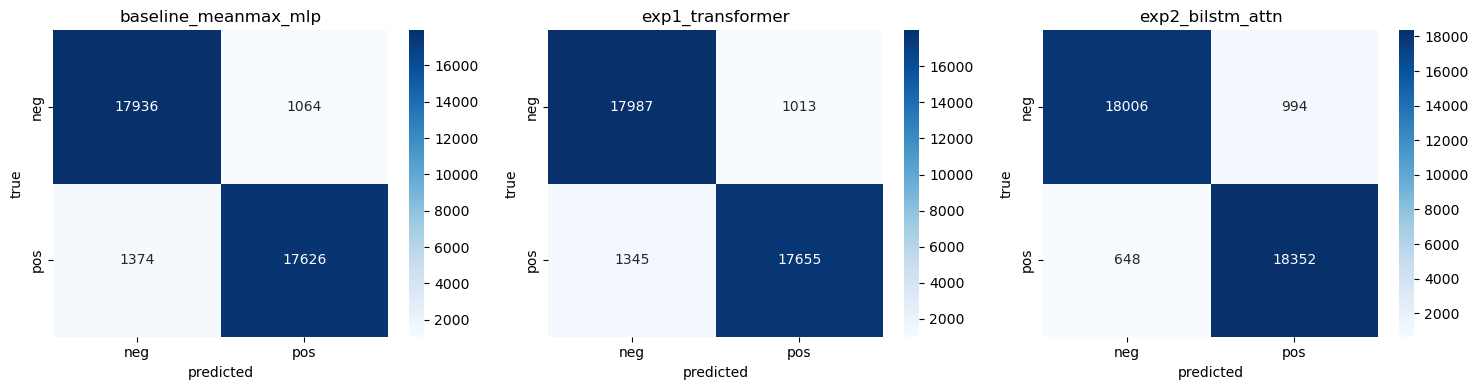

,comparison,only_baseline_correct,only_exp_correct,statistic,p_value
0,baseline_meanmax_mlp vs exp1_transformer,503,583,5.746777,1.651893e-02
1,baseline_meanmax_mlp vs exp2_bilstm_attn,610,1406,313.504464,3.765428e-70


In [13]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, (name, cm) in zip(ax, cms.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=a, xticklabels=["neg","pos"], yticklabels=["neg","pos"]); a.set_title(name); a.set_xlabel("predicted"); a.set_ylabel("true")
plt.tight_layout(); plt.show()

# McNemar: baseline vs each experimental model
base = "baseline_meanmax_mlp"; base_ok = (test_probs[base] > .5) == y_test; mc = []
for name in [n for n in models if n != base]:
    ok = (test_probs[name] > .5) == y_test
    b = int((base_ok & ~ok).sum()); c = int((~base_ok & ok).sum())
    table = [[int((base_ok & ok).sum()), b], [c, int((~base_ok & ~ok).sum())]]
    t = mcnemar(table, exact=(b + c < 25), correction=True)
    mc.append(dict(comparison=f"{base} vs {name}", only_baseline_correct=b, only_exp_correct=c, statistic=t.statistic, p_value=t.pvalue))
pd.DataFrame(mc)

### Manual error review 

In [14]:
AUDIT = res.loc[[m for m in models if m != "baseline_meanmax_mlp"], "f1_macro"].idxmax()
p = test_probs[AUDIT]; pred = (p > .5).astype(int)
err = test_df.assign(prob_pos=p, pred=pred).reset_index(names="test_idx"); err = err[err.pred != err.label]

fp = err[(err.label == 0)].nlargest(5, "prob_pos").assign(bucket="confident_FP")
fn = err[(err.label == 1)].nsmallest(5, "prob_pos").assign(bucket="confident_FN")
used = set(fp.test_idx) | set(fn.test_idx)
near = err[~err.test_idx.isin(used)].assign(d=lambda d: (d.prob_pos - .5).abs()).nsmallest(5, "d").drop(columns="d").assign(bucket="near_threshold")
used |= set(near.test_idx)
slice_err = {s: 1 - ((pred == y_test)[m]).mean() for s, m in SLICES.items()}; worst = max(slice_err, key=slice_err.get)
print("slice error rates:", {k: round(v,4) for k,v in slice_err.items()}, "-> worst:", worst)
in_slice = err[err.test_idx.map(lambda i: SLICES[worst][i]) & ~err.test_idx.isin(used)]
sl = in_slice.sample(min(5, len(in_slice)), random_state=SEED).assign(bucket=f"slice: {worst}")

audit = pd.concat([fp, fn, near, sl])[["bucket","test_idx","label","prob_pos","text"]]
audit["error_type"] = ""; audit["proposed_testable_fix"] = ""
audit.to_csv(f"error_audit_{MEMBER}_{AUDIT}.csv", index=False)
pd.set_option("display.max_colwidth", None); audit

slice error rates: {'short (<=q25 words)': 0.0465, 'long (>=q75 words)': 0.0465, 'has negation': 0.0436, 'has contrast (but/however/although)': 0.0474, "exclamation-heavy (>=3 '!')": 0.0281} -> worst: has contrast (but/however/although)


,bucket,test_idx,label,prob_pos,text,error_type,proposed_testable_fix
29330,confident_FP,29330,0,0.999985,"Wow love the place and everything is very clean and new!\n\nGreat place to come and relax worth a try!\n\nCheers,\n\nEric Van Nguyen\nVisited April 2012",,
29525,confident_FP,29525,0,0.999878,"I tried to love it, had a chocolate chip cookie and milk once, and was satisfied.. took my date here after lunch next door and went all out on a vietnamese iced coffee ice cream and red velvet cookie sandwich.. the cookie was too hard and made it not enjoyable for me =(\n\nBut the ice cream was delicious !",,
1560,confident_FP,1560,0,0.999787,"Home of the incredible exploding burrito. This place is awesome if you want to wear your food. Actually, that might be better than eating it. :(",,
23815,confident_FP,23815,0,0.999774,"This is the neighborhood Foodland that has the bare necessities needed to sustain a pantry or for when the next snowstorm of the century is a day away and you only have minutes to get TP, bread and milk. \n\nThe bakery here is tops, small selection, but really well made specialities. Huge brownies, iced and moist. They are easily 5 inch squares, topped with things like Oreo cookies, nuts, sprinkles, and other yummy delights. The best thing I found is the individual pineapple upside-down cakes. Perfect for one person, these are just like the big ones, same buttery cake, same crunchy edges from the brown sugar melting as it bakes, and that almost candied pineapple that has bece one of my favorite desserts of all time.\n\nTry the foccacia dripping with evoo, fresh basil and tomatoes and mozzarella cheese, you'll never buy pizzeria pizza ever again. Take a few home and pop them in the oven and enjoy. \n\nI come here when I need the staples of the pantry like eggs, milk, even a pound of ground beef. The deli isn't the greatest but it will do in a pinch. Good rotisserie chickens too.",,
408,confident_FP,408,0,0.999669,"Though I'm a Copper enthusiast when it comes to getting my Indian fix in Charlotte, I'd heard that Maharani was a cheaper but tasty option, so we ordered from there a few nights ago. \n\nCopper is definitely still my place, but Maharani was fine enough. First of all, the food came very quickly, which is rare. Usually indian food, good indian good, takes at least 30-45 minutes. We got our order in like 30, which was great 'cause we were starving. \n\nThe Tikka Masala was spicy and pretty good, but it wasn't as thick and saucy as i like. The salad was just so-so. The Naan were all amazing. Definitely the highlight.",,
21813,confident_FN,21813,1,0.000321,"Our flight arrived to Vegas earlier than excepted, so we expected our room not to be ready. When we arrived at the hotel on May 19th, the front desk girl offered us a room that was ready on the 28th floor that wasn't facing the Bellagio fountain. I booked a corner view suite had requested a room on a high floor with a Bellagio fountain view when I first made the reservation. There are 56 floors at the hotel. She then said there was a room on the 30th floor with a view of the Bellagio fountain, but it wasn't ready. She continued to look for rooms, which she then said that there was a room on the 50th room with a Bellagio fountain view, but it wasn't ready yet either. We agreed to wait for that room to be cleaned, which she said it would be couple of hours before it would be ready. We waited a couple of hours by walking around the area before calling to check to see if the room was ready yet. I was transferred to housekeeping, who said it wasn't ready yet and they would call me back when it was. After eating and walking around some more for a couple more hours without hearing back from anyone, we decided to go back to the hotel and was told that the room was ready. It would of been nice if they had called me as they told me they would\n\nUpon inspecting the room, we found a dirty fork and knife in the dishwasher, as well as trash in a trash can underneath t

## 2.3 Comparative analysis

,accuracy,f1_macro,mcc,roc_auc,pr_auc,brier,ece,n_params,train_time_s,examples_per_sec,peak_gpu_mem_mb,peak_cpu_rss_mb
model,,,,,,,,,,,,
baseline_meanmax_mlp,0.9358,0.9358,0.8718,0.9831,0.9835,0.0481,0.0094,3906305,294.6332,13684.8121,294.5176,2571.1797
exp1_transformer,0.9379,0.9379,0.8760,0.9852,0.9858,0.0463,0.0171,4130945,1294.7821,2335.5281,1979.7778,2564.6406
exp2_bilstm_attn,0.9568,0.9568,0.9137,0.9920,0.9922,0.0332,0.0164,5097794,3353.6422,751.4219,892.3252,1336.2656


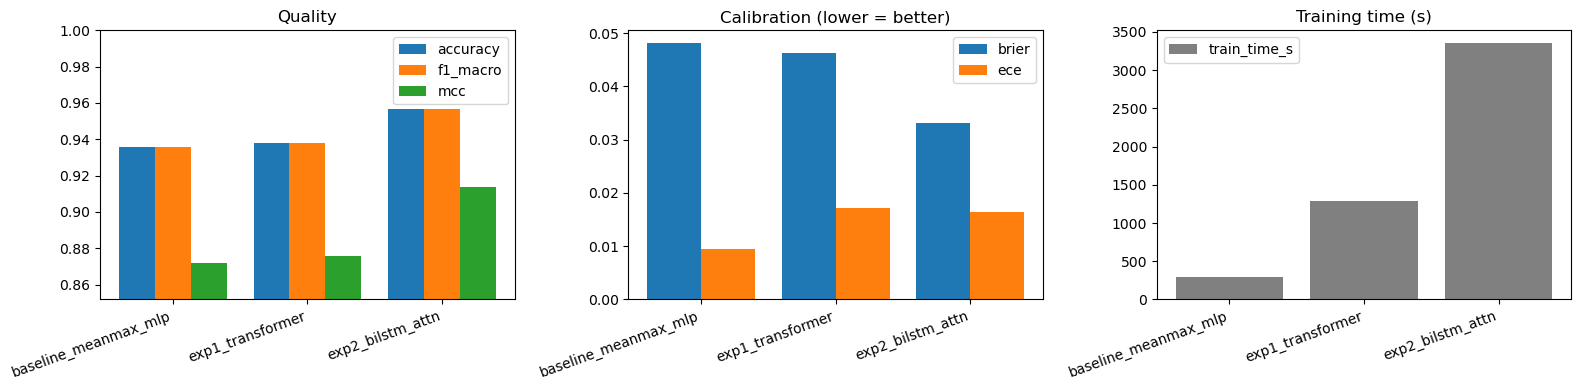

,short (<=q25 words),long (>=q75 words),has negation,has contrast (but/however/although),exclamation-heavy (>=3 '!')
model,,,,,
baseline_meanmax_mlp,0.0635,0.0667,0.0695,0.0740,0.0481
exp1_transformer,0.0632,0.0633,0.0666,0.0712,0.0454
exp2_bilstm_attn,0.0465,0.0465,0.0436,0.0474,0.0281


In [15]:
cols = ["accuracy","f1_macro","mcc","roc_auc","pr_auc","brier","ece","n_params","train_time_s","examples_per_sec","peak_gpu_mem_mb","peak_cpu_rss_mb"]
summary = res[cols].round(4); display(summary)

def grouped_bar(ax, df, columns, title, ylim=None, colors=None):
    x = np.arange(len(df)); w = 0.8 / len(columns)
    for j, c in enumerate(columns):
        ax.bar(x - 0.4 + w/2 + j*w, df[c].values, w, label=c, color=None if colors is None else colors[j])
    ax.set_xticks(x); ax.set_xticklabels(df.index, rotation=20, ha="right")
    ax.set_title(title); ax.legend()
    if ylim: ax.set_ylim(*ylim)

q = ["accuracy","f1_macro","mcc"]
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
grouped_bar(ax[0], summary, q, "Quality", ylim=(summary[q].min().min() - .02, 1))
grouped_bar(ax[1], summary, ["brier","ece"], "Calibration (lower = better)")
grouped_bar(ax[2], summary, ["train_time_s"], "Training time (s)", colors=["gray"])
plt.tight_layout(); plt.show()

slice_cols = [c for c in res.columns if c.startswith("slice_err")]
display(res[slice_cols].rename(columns=lambda c: c.replace("slice_err | ", "")).round(4))

## 2.3 Comparative Analysis and Observations

**Setup.** All three models learn their embeddings from scratch; no pretrained embeddings or pretrained language models were used. After cleaning, the dataset contained 504,000 training examples, 56,000 validation examples, and the full 38,000-review official test set. The vocabulary contained 30,002 entries, including special tokens, with a minimum frequency of 2 and a maximum vocabulary size of 30,000. Reviews were padded or truncated to 200 tokens. All three models were trained on an NVIDIA GeForce RTX 3060 Laptop GPU with an Intel64 CPU using 20 threads and 16.8 GB RAM.

| Model | Accuracy [95% CI] | Macro-F1 | MCC | ROC-AUC | PR-AUC | Brier | ECE | Train time | Peak GPU memory |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Baseline (`MeanMaxMLP`) | 93.58% [93.35, 93.83] | 0.9358 | 0.8718 | 0.9831 | 0.9835 | 0.0481 | 0.0094 | 295 s | 295 MB |
| Exp 1 (`TinyTransformer`) | 93.79% [93.56, 94.03] | 0.9379 | 0.8760 | 0.9852 | 0.9858 | 0.0463 | 0.0171 | 1,295 s | 1,980 MB |
| Exp 2 (`BiLSTMAttn`) | **95.68% [95.47, 95.87]** | **0.9568** | **0.9137** | **0.9920** | **0.9922** | **0.0332** | 0.0164 | 3,354 s | 892 MB |

### Comparison of my experimental models

- **The BiLSTM with attention was the strongest model.** It achieved the highest accuracy, macro-F1, MCC, ROC-AUC, and PR-AUC. It also achieved the lowest Brier score, indicating better probability quality than the baseline and Transformer. It improved accuracy by 2.10 percentage points over the baseline and 1.88 percentage points over the Transformer. Its 95% confidence interval does not overlap with the confidence intervals of the other two models, indicating a clear performance gap.

- **The BiLSTM improvement was statistically significant.** In the McNemar comparison against the baseline, the baseline was correct on 610 examples where the BiLSTM was incorrect, while the BiLSTM was correct on 1,406 examples where the baseline was incorrect. The test produced a p-value of approximately `3.77 × 10⁻⁷⁰`, showing that the BiLSTM's improvement was statistically significant.

- **The Transformer improvement was statistically significant but practically small.** The Transformer was correct on 583 examples where the baseline was incorrect, while the baseline was correct on 503 examples where the Transformer was incorrect. The McNemar test produced a p-value of `0.0165`, which is below 0.025 after Bonferroni correction for two comparisons. However, the Transformer produced only 80 net additional correct predictions compared with the baseline, so its practical improvement was modest.

- **The BiLSTM performed best on every robustness slice.**

| Error rate by slice | Baseline | Transformer | BiLSTM |
|---|---:|---:|---:|
| Short reviews | 6.35% | 6.32% | **4.65%** |
| Long reviews | 6.67% | 6.33% | **4.65%** |
| Reviews containing negation | 6.95% | 6.66% | **4.36%** |
| Reviews containing contrast words | 7.40% | 7.12% | **4.74%** |
| Exclamation-heavy reviews | 4.81% | 4.54% | **2.81%** |

The largest improvement occurred on reviews containing negation and contrast words. This suggests that sequential modeling helped the BiLSTM understand negation scope and relationships between clauses more effectively than the pooling-based baseline. The Transformer improved over the baseline, but its slice-level gains were relatively small.

- **Error direction differed across models.** The baseline and Transformer produced more false negatives than false positives, meaning they missed more positive reviews than they incorrectly labeled as positive. The BiLSTM produced 994 false positives and 648 false negatives, showing a lower false-negative count and better detection of positive reviews.

- **Validation and test performance were consistent.** The BiLSTM achieved 95.63% validation accuracy and 95.68% test accuracy. The close values suggest that the model generalized well and was not overfitting strongly to the validation set.

### Comparison with teammate Nikhil Kanaparthi

Nikhil used a different model lineup consisting of a mean-pooling baseline, a CNN with kernel widths 3, 5, and 7, and a bidirectional GRU. His models also learned embeddings from scratch and did not use pretrained language models.

| Member | Model | Accuracy | Macro-F1 | ROC-AUC | PR-AUC | MCC | Brier | ECE |
|---|---|---:|---:|---:|---:|---:|---:|---:|
| Samruddhi | MeanMaxMLP baseline | 0.9358 | 0.9358 | 0.9831 | 0.9835 | 0.8718 | 0.0481 | 0.0094 |
| Samruddhi | TinyTransformer | 0.9379 | 0.9379 | 0.9852 | 0.9858 | 0.8760 | 0.0463 | 0.0171 |
| Samruddhi | BiLSTM + attention | **0.9568** | **0.9568** | **0.9920** | **0.9922** | **0.9137** | **0.0332** | 0.0164 |
| Nikhil | Mean-pooling baseline | 0.9362 | 0.9362 | 0.9816 | 0.9813 | 0.8723 | 0.0480 | **0.0062** |
| Nikhil | CNN | 0.9491 | 0.9491 | 0.9892 | 0.9895 | 0.8983 | 0.0382 | 0.0134 |
| Nikhil | BiGRU | 0.9521 | 0.9521 | 0.9897 | 0.9897 | 0.9042 | 0.0378 | 0.0221 |

The best overall model was the Samruddhi BiLSTM with attention. It exceeded Nikhil's best BiGRU by approximately 0.47 percentage points in accuracy and macro-F1, and by approximately 0.96 percentage points in MCC. The attention mechanism likely helped the BiLSTM focus on sentiment-bearing words while the bidirectional recurrent structure captured context from both directions.

Nikhil's CNN was also effective, improving substantially over his mean-pooling baseline while requiring less sequential computation than the BiGRU. The comparison shows that convolutional and recurrent architectures both improved over simple pooling, while the attention-based BiLSTM achieved the strongest predictive performance in this team experiment.

Training time and memory should not be compared as absolute measures because the experiments used different hardware: my models used an NVIDIA RTX 3060 GPU, while Nikhil's models used an Apple GPU through MPS.

### Strengths

- **Best predictive performance.** The BiLSTM with attention achieved the highest accuracy, macro-F1, MCC, ROC-AUC, and PR-AUC across all models.
- **Strong robustness.** The BiLSTM achieved the lowest error rate on every evaluated slice.
- **Useful baseline.** The MeanMaxMLP baseline trained quickly, processed 13,684 examples per second, and used only 295 MB of GPU memory.
- **Reasonable calibration.** All three models had ECE values below 0.02. The baseline had the lowest ECE at 0.0094.
- **Meaningful statistical improvement.** The McNemar test confirmed that both experimental models improved over the baseline, with a particularly large improvement from the BiLSTM.

### Weaknesses and limitations

- **Higher computational cost.** The BiLSTM required approximately 3,354 seconds to train, compared with 295 seconds for the baseline. It also processed fewer examples per second.
- **The Transformer provided limited practical improvement.** It required approximately 4.4 times the baseline's training time and used the most GPU memory, but improved accuracy by only 0.21 percentage points over the baseline.
- **ECE was not lowest for the best-performing model.** Although the BiLSTM achieved the best Brier score, its ECE was higher than the baseline's ECE.
- **Contrast reviews remained difficult.** Reviews containing words such as `but`, `however`, and `although` had the highest error rates for all three models. These reviews often contain both positive and negative opinions.
- **Truncation can remove evidence.** Reviews longer than 200 tokens were truncated, so the decisive sentiment may have been removed from the model input.
- **Preprocessing can remove sentiment cues.** Removing punctuation, special characters, and emoticons may remove information useful for sarcasm, irony, and informal sentiment.
- **Single-seed evaluation.** Each model used one random seed, so run-to-run variation was not measured.
- **Overlapping slices.** The slice categories overlap and are based on keyword rules, so they should be interpreted as diagnostic evidence rather than completely independent groups.

### Findings from the 20-example error audit

The manual review included five confident false positives, five confident false negatives, five near-threshold errors, and five contrast-word slice failures.

The main error patterns were:

- mixed sentiment, where praise and complaints appeared in the same review;
- sarcasm and irony, including reviews with emoticons or contradictory wording;
- truncation, where the decisive opinion appeared later in a long review;
- lukewarm or comparative language such as “fine enough” or “still prefer”;
- numeric ratings such as `2/5` and `3.5/5`;
- implicit negative sentiment expressed through context rather than explicit negative words;
- slang, misspellings, and elongated words;
- possible label noise or stale ratings.

The proposed testable improvements were head-and-tail truncation, preserving emoticons, adding rating-pattern tokens, using subword tokenization, adding last-state pooling, increasing the sequence length, and blind relabeling of highly confident errors to estimate a possible label-noise ceiling.

### Possible improvements and future work

- Train multiple seeds and report mean and standard deviation.
- Train for longer or use a larger early-stopping budget.
- Use head-and-tail truncation so that the beginning and conclusion of long reviews are preserved.
- Preserve emoticons, rating expressions, capitalization information, and repeated-letter patterns.
- Test subword tokenization for slang, misspellings, and out-of-vocabulary words.
- Apply temperature scaling on the validation set to improve calibration.
- Ensemble the BiLSTM and Transformer because they make different errors.
- Test a hybrid CNN-BiLSTM model to combine local phrase features with sequential context.
- Evaluate the models on additional slices involving sarcasm, numeric ratings, mixed sentiment, and long reviews.
- Conduct blind relabeling of highly confident errors to estimate the effect of label noise.

### Filling in the error labels

In [17]:
labels = {
 # ---- confident false positives (true neg, predicted pos) ----
 29330: ("label noise", "Have two people re-label the 50 most confident errors blind to the gold label; report the share that disagree as a noise ceiling on accuracy"),
 29525: ("mixed sentiment (praise + complaint)", "Concatenate max-pooled and last-state BiLSTM features with attention pooling; compare error on the contrast-word slice"),
 1560:  ("sarcasm / irony (+ emoticon removed)", "Keep emoticons (:( :) =() as tokens instead of stripping them; compare error on reviews containing emoticons"),
 23815: ("mixed sentiment or label noise (check ending)", "Re-label blind (as above); if the ending is a complaint, test head+tail truncation on long reviews"),
 408:   ("lukewarm / comparative ('fine enough', 'still prefer X')", "Ensemble BiLSTM + Transformer probabilities; compare error in the 0.4-0.6 confidence band"),
 # ---- confident false negatives (true pos, predicted neg) ----
 21813: ("truncation / late resolution (check ending)", "Use head+tail truncation (first 100 + last 100 tokens) or MAX_LEN=400; re-measure error on the long-review slice"),
 20061: ("topic-sentiment confound + truncation (humour about a trash facility)", "Head+tail truncation and a larger MAX_LEN; re-measure long-review error"),
 22807: ("label noise (text is clearly negative; 'EDIT' line suggests a stale rating)", "Re-label blind; measure error on reviews containing 'EDIT' or 'UPDATE'"),
 21215: ("reported events / third-party narrative (check ending)", "Add last-N-token pooling to the BiLSTM; compare error on reviews with quotes or reported speech"),
 16700: ("sarcasm / irony (ALL-CAPS complaints, 'A++++')", "Stop lowercasing blindly: add an ALL-CAPS ratio feature and keep tokens like 'a++++'; compare error on caps-heavy reviews"),
 # ---- near-threshold errors ----
 28040: ("mixed sentiment (explicit star verdict)", "Ensemble BiLSTM + Transformer; compare accuracy on reviews with p in 0.4-0.6"),
 9912:  ("mixed sentiment + truncation (570 words)", "Head+tail truncation; compare error on reviews longer than MAX_LEN"),
 14409: ("mixed sentiment (praise first, complaint later)", "Ensemble BiLSTM + Transformer; compare error in the 0.4-0.6 band"),
 7242:  ("numeric ratings in text ('2/5', '3.5/5') destroyed by cleaning", "Map patterns like 'x/5' to rating tokens (<rating_low>, <rating_high>); compare error on reviews containing 'x/5'"),
 3822:  ("implicit negative / past-tense praise ('was a 5-star place at one time')", "Remove 'was', 'used', 'once', 'anymore' from the stopword list; compare error on reviews with 'used to', 'anymore', 'at one time'"),
 # ---- slice failures (contrast words) ----
 11908: ("contrast: final clause decisive ('Still great coffee') + emoticons stripped", "Keep emoticons and add last-state pooling; compare contrast-slice error"),
 23417: ("elongated words (OOV) + trailing caveat", "Collapse letters repeated 3+ times ('soooo' -> 'so'); compare error on reviews containing elongated words"),
 16460: ("long mixed review (658 words) + truncation", "Head+tail truncation; compare long-review error"),
 13040: ("slang / misspellings / profanity (check)", "Use subword (BPE) tokens trained on this corpus; compare OOV rate and error on high-OOV reviews"),
 1253:  ("implicit negative (event descriptions, few sentiment words)", "Train a 2-layer BiLSTM; compare error on the contrast slice and overall"),
}
a = pd.read_csv(f"error_audit_{MEMBER}_{AUDIT}.csv")
a["error_type"] = a.test_idx.map(lambda i: labels[i][0])
a["proposed_testable_fix"] = a.test_idx.map(lambda i: labels[i][1])
a.to_csv(f"error_audit_{MEMBER}_{AUDIT}.csv", index=False)
print(a[["bucket", "test_idx", "error_type"]].to_string(index=False))

                                    bucket  test_idx                                                                  error_type
                              confident_FP     29330                                                                 label noise
                              confident_FP     29525                                        mixed sentiment (praise + complaint)
                              confident_FP      1560                                        sarcasm / irony (+ emoticon removed)
                              confident_FP     23815                               mixed sentiment or label noise (check ending)
                              confident_FP       408                    lukewarm / comparative ('fine enough', 'still prefer X')
                              confident_FN     21813                                 truncation / late resolution (check ending)
                              confident_FN     20061       topic-sentiment confound + truncation 

## Export for the team comparison

In [18]:
import os, json, shutil, platform, sys, datetime, importlib.metadata as md
import matplotlib.pyplot as plt

ROOT = f"{MEMBER}_task2"
for d in ["checkpoints", "metrics", "outputs", "raw_logs", "src"]: os.makedirs(f"{ROOT}/{d}", exist_ok=True)
conv = lambda o: o.item() if hasattr(o, "item") else str(o)

# architecture hyperparameters (keep in sync with CONFIGS)
ARCH = {
 "baseline_meanmax_mlp": dict(type="MeanMaxMLP", emb_dim=128, hidden=256, dropout=0.35),
 "exp1_transformer":     dict(type="TinyTransformer", emb_dim=128, heads=4, layers=2, ff=256, max_len=MAX_LEN, dropout=0.2),
 "exp2_bilstm_attn":     dict(type="BiLSTMAttn", emb_dim=160, hidden=128, layers=1, dropout=0.4),
}
n_empty = lambda df: int((df.tokens.str.len() == 0).sum())

# ---- config.json ----
config = dict(seed=SEED, device=str(DEVICE), hardware=HW, operating_system=platform.system(), machine=platform.machine(),
    processor=platform.processor(), vocabulary_size=V, max_length=MAX_LEN, min_frequency=MIN_FREQ, max_vocab=MAX_VOCAB,
    validation_fraction=VAL_FRAC, train_examples=len(train_df), validation_examples=len(val_df), test_examples=len(test_df),
    train_cleaning=dict(original_rows=len(ds["train"]), subsample=N_TRAIN, empty_after_preprocessing=n_empty(train_df)),
    test_cleaning=dict(original_rows=len(ds["test"]), empty_after_preprocessing=n_empty(test_df)),
    models={n: dict(architecture=ARCH[n], lr=CONFIGS[n]["lr"], epochs=CONFIGS[n]["epochs"], batch_size=CONFIGS[n]["bs"]) for n in CONFIGS})
json.dump(config, open(f"{ROOT}/config.json", "w"), indent=2, default=conv)

# ---- metrics ----
report = dict(models=res.reset_index().to_dict("records"), mcnemar=mc, confusion_matrices={n: cm.tolist() for n, cm in cms.items()})
for p in [f"{ROOT}/metrics_report.json", f"{ROOT}/metrics/metrics_report.json"]: json.dump(report, open(p, "w"), indent=2, default=conv)
res.to_csv(f"{ROOT}/metrics_report.csv")
np.savez_compressed(f"{ROOT}/metrics/test_probs.npz", y_test=y_test, **test_probs)   # for cross-member McNemar

# ---- history, vocabulary, checkpoints, log ----
json.dump({n: h.to_dict("records") for n, h in hists.items()}, open(f"{ROOT}/history.json", "w"), indent=2, default=conv)
json.dump(stoi, open(f"{ROOT}/vocabulary.json", "w"))
for n, m in models.items(): torch.save(m.state_dict(), f"{ROOT}/checkpoints/{n}.pt")
with open(f"{ROOT}/raw_logs/training_log.txt", "w") as f:
    f.write(f"Hardware: {HW}\n")
    for n in models:
        f.write(f"\n== {n} ==\n{ARCH[n]}\n{sysinfo[n]}\n{hists[n].to_string(index=False)}\n")

# ---- plots ----
fig, ax = plt.subplots(1, len(cms), figsize=(5*len(cms), 4))
for a_, (n, cm) in zip(ax, cms.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=a_, xticklabels=["neg","pos"], yticklabels=["neg","pos"]); a_.set_title(n)
plt.tight_layout(); plt.savefig(f"{ROOT}/outputs/confusion_matrices.png", dpi=150); plt.close()

fig, ax = plt.subplots(figsize=(7, 4))
for n, h in hists.items(): ax.plot(h.epoch, h.val_acc, marker="o", label=n)
ax.set_xlabel("epoch"); ax.set_ylabel("validation accuracy"); ax.legend()
plt.tight_layout(); plt.savefig(f"{ROOT}/outputs/training_curves.png", dpi=150); plt.close()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
c = train_df.label.value_counts().sort_index(); ax[0].bar(["neg","pos"], c.values); ax[0].set_title("Class distribution (train)")
ax[1].hist(tok_len.clip(upper=400), bins=60); ax[1].set_title("Tokens per review (clipped at 400)")
plt.tight_layout(); plt.savefig(f"{ROOT}/outputs/class_and_length_distribution.png", dpi=150); plt.close()

# ---- markdown deliverables ----
cols = ["accuracy","f1_macro","mcc","roc_auc","pr_auc","brier","ece","n_params","train_time_s","examples_per_sec","peak_gpu_mem_mb","peak_cpu_rss_mb"]
with open(f"{ROOT}/results.md", "w") as f:
    f.write(f"# Task 2 results ({MEMBER})\n\nHardware: {HW}\n\n| model | " + " | ".join(cols) + " |\n|" + "---|"*(len(cols)+1) + "\n")
    for n, r in res.iterrows(): f.write(f"| {n} | " + " | ".join(f"{r[c]:.4f}" if isinstance(r[c], float) else str(r[c]) for c in cols) + " |\n")
slice_cols = [c for c in res.columns if c.startswith("slice_")]
with open(f"{ROOT}/failure_analysis.md", "w") as f:
    f.write("# Robustness by data slice\n\n| metric | " + " | ".join(res.index) + " |\n|" + "---|"*(len(res)+1) + "\n")
    for c in slice_cols: f.write(f"| {c} | " + " | ".join(f"{res.loc[n, c]:.4f}" for n in res.index) + " |\n")
audit_csv = f"error_audit_{MEMBER}_{AUDIT}.csv"
if os.path.exists(audit_csv):
    au = pd.read_csv(audit_csv).fillna("")
    with open(f"{ROOT}/error_review.md", "w", encoding="utf-8") as f:
        f.write(f"# Manual error review ({AUDIT})\n\n")
        for i, r in au.iterrows():
            f.write(f"### {i+1}. {r.bucket} | test_idx {r.test_idx} | true={'pos' if r.label==1 else 'neg'} | P(pos)={r.prob_pos:.3f}\n\n> {str(r.text)[:1200]}\n\n**Error type:** {r.error_type}\n\n**Proposed testable fix:** {r.proposed_testable_fix}\n\n")

# ---- manifest, requirements, README, notebook copy ----
pk = {}
for p in ["torch","numpy","pandas","scikit-learn","statsmodels","nltk","datasets","matplotlib","seaborn","psutil"]:
    try: pk[p] = md.version(p)
    except Exception: pk[p] = None
json.dump(dict(created=datetime.datetime.now().isoformat(timespec="seconds"), python=sys.version.split()[0], packages=pk,
               dataset="fancyzhx/yelp_polarity (Hugging Face)", member=MEMBER, seed=SEED, audited_model=AUDIT),
          open(f"{ROOT}/run_manifest.json", "w"), indent=2)
open(f"{ROOT}/requirements.txt", "w").write("\n".join(f"{k}=={v}" for k, v in pk.items() if v))
open(f"{ROOT}/README.md", "w").write(f"# Task 2: Yelp Polarity sentiment ({MEMBER})\nRun `src/yelp_polarity_task2.ipynb` top to bottom. Hardware: {HW}\n")
if os.path.exists("yelp_polarity_task2.ipynb"): shutil.copy("yelp_polarity_task2.ipynb", f"{ROOT}/src/")
print(sorted(os.listdir(ROOT)))

['README.md', 'checkpoints', 'config.json', 'error_review.md', 'failure_analysis.md', 'history.json', 'metrics', 'metrics_report.csv', 'metrics_report.json', 'outputs', 'raw_logs', 'requirements.txt', 'results.md', 'run_manifest.json', 'src', 'vocabulary.json']
